In [1]:
# all other libraries
import sys
import numpy as np 
%matplotlib inline
sys.path.append('C:/Users/enyanglab/Desktop/code/modules')
import glob, os
import fish

import matplotlib.pyplot as plt
%matplotlib inline

import importEphys as ime
import ephys4normal as imenorm
import conv as conv
import volTools as volt
import tifffile

import time
import glob, os
import showit as showit
import scipy.stats as stats

from scipy  import stats
from scipy.signal import savgol_filter as savgol
import pandas as pd

import compress as compress

from fileTools import stack_to_tif, im_loader
import compress as compress

from fileTools import stack_to_tif, im_loader

from scipy.signal import savgol_filter as savgol
from fish.ephys import ephys


### Parse behavior file

In [3]:
import shutil
h=shutil.disk_usage("D:/")

print ("Total: %d GiB" % (h.total / (2**30)))
print ("Used: %d GiB" % (h.used / (2**30)))
print ("Free: %d GiB" % (h.free / (2**30)))

Total: 7451 GiB
Used: 133 GiB
Free: 7318 GiB


In [4]:
os.listdir('D:/Millen/20241021/')

['HCDf1.10chFlt',
 'HCDf1gu.10chFlt',
 'HCDf2',
 'HCDf2.10chFlt',
 'HCDf3.10chFlt',
 'NDf1',
 'NDf1-1.10chFlt',
 'NDf1.10chFlt',
 'NDf1gu.10chFlt',
 'test',
 'test.10chFlt']

In [117]:
#date='20190307/'
#paradiam='learning/'
#today_dir=beh_home+date#+paradiam

rootDir='D:/Millen/20241021/'
#behDir = proc_home+date+paradiam

behDir=rootDir#+'20240712/'
if not os.path.exists(behDir):
    
       os.makedirs(behDir)
      
        
bothDir= behDir+'both/'       
        
boutDir= behDir+'all_bouts/'   
fnames = glob.glob(behDir + '**HCDf2**.10ch*')
fnames.sort()
fnames

['D:/Millen/20241021\\HCDf2.10chFlt']

In [119]:
behDir

'D:/Millen/20241021/'

In [121]:

eph = ime.import10ch(fnames[0])
bh_ch0=eph['fltCh0']
bh_ch1=eph['fltCh1']
visual_input=eph['drift']


(-0.0001, 0.0001)

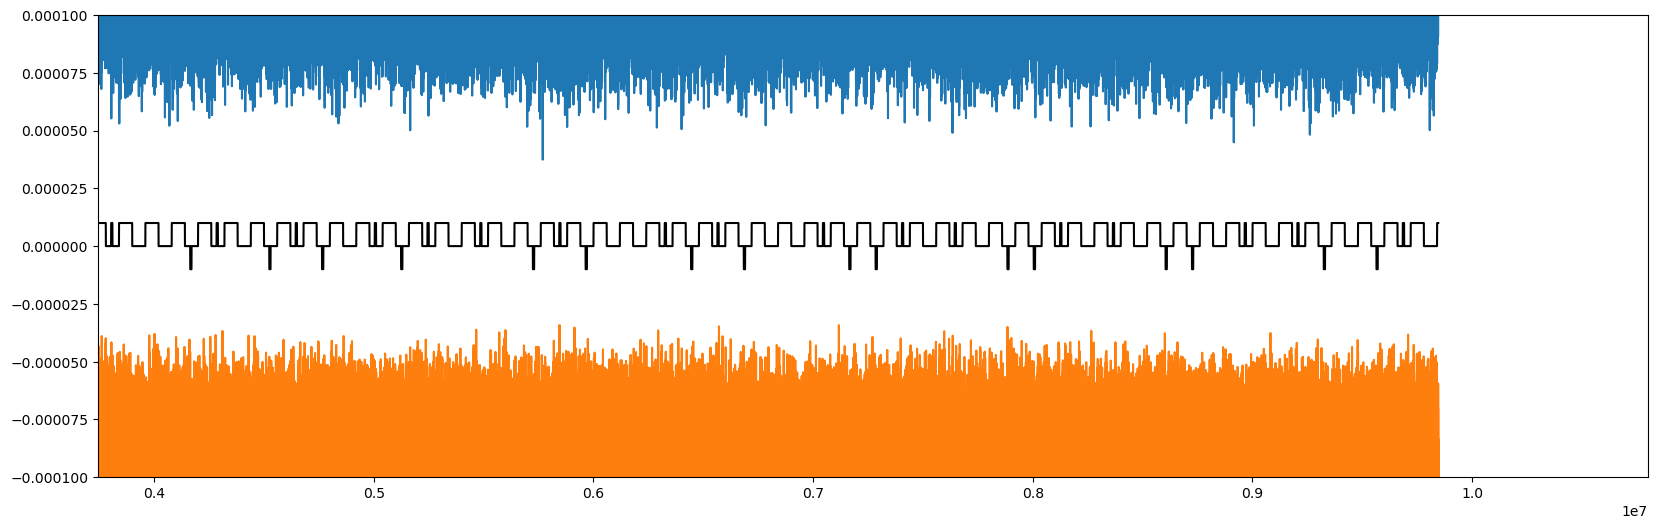

In [122]:
plt.figure(figsize=(20,6))
plt.plot(bh_ch0)
plt.plot((-1)*bh_ch1)
#plt.plot(ephyst[8]/35)
plt.plot(visual_input/100000,'k')
plt.xlim(10.4*60*6000,30.0*60*6000)
plt.ylim(-0.0001,0.0001)

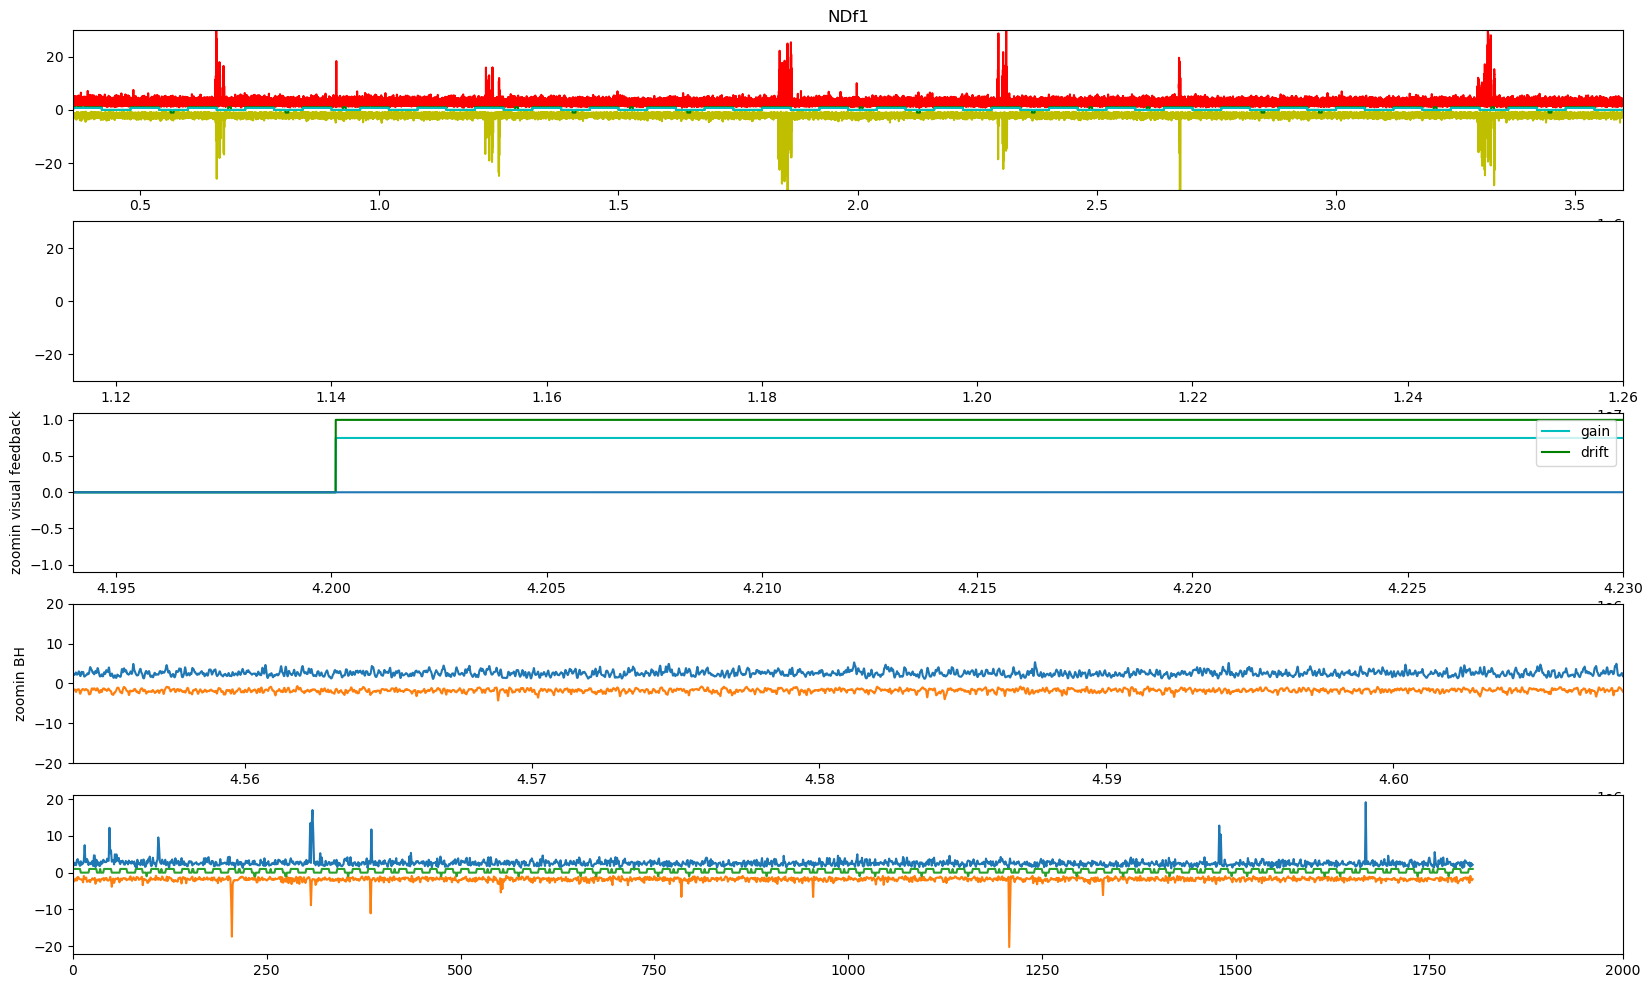

are both channels usable? yes or no


 yes


Selecte your better channel: 0 or 1: top is 0, bottom is 1


 1


bh_ch1
choose scaling thr vale for channel 0


 1.6


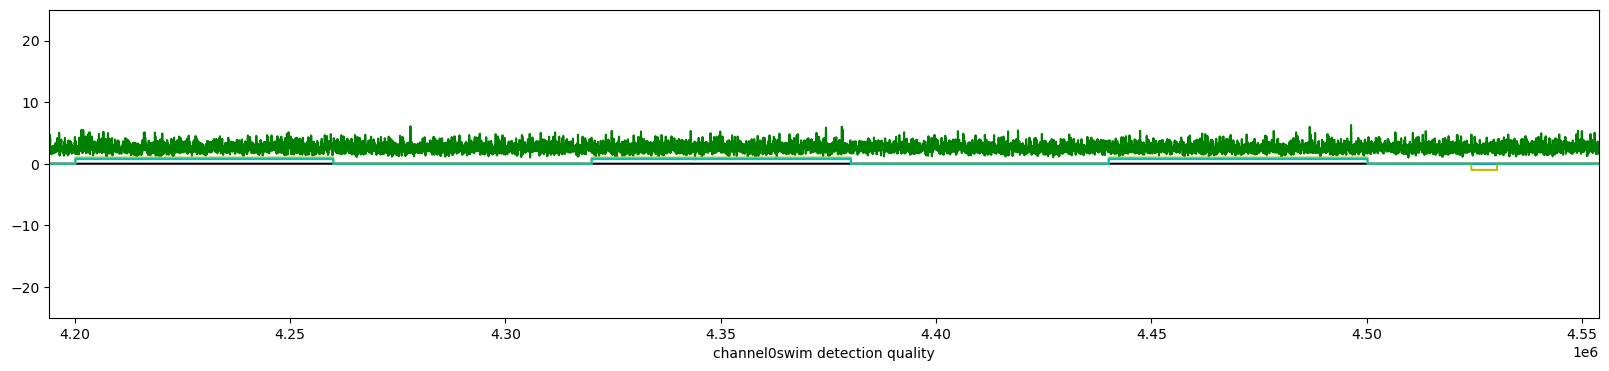

C:\Users\enyanglab\AppData\Local\Temp\ipykernel_23804\239986118.py:347: RuntimeWarning: Mean of empty slice.
  bout_interval[i]=(swim_on_ind[1:]-swim_off_ind[:-1]).mean()
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


choose scaling thr vale for channel 1


 1.6


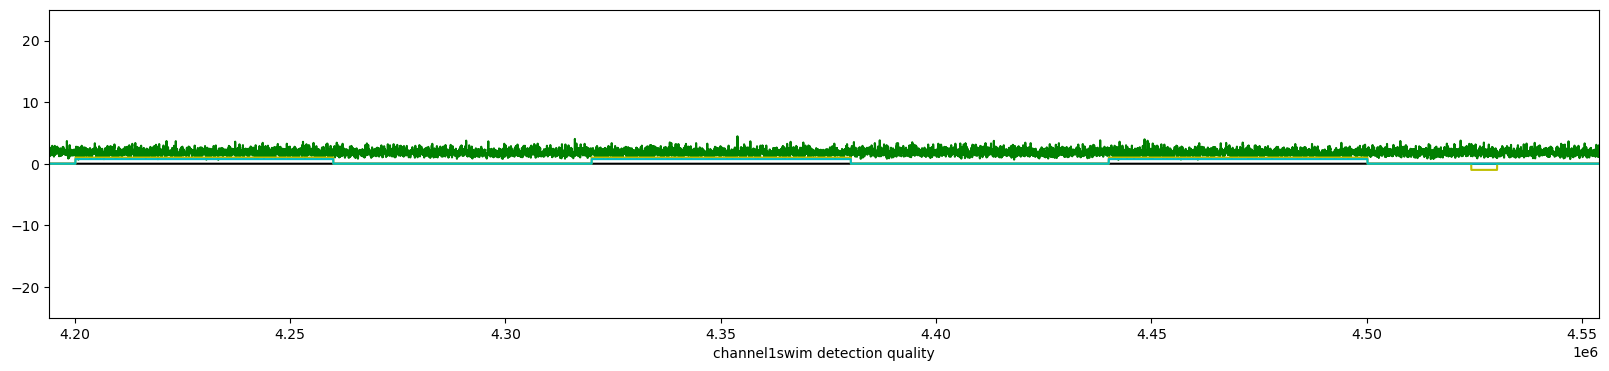

C:\Users\enyanglab\AppData\Local\Temp\ipykernel_23804\239986118.py:347: RuntimeWarning: Mean of empty slice.
  bout_interval[i]=(swim_on_ind[1:]-swim_off_ind[:-1]).mean()
C:\ProgramData\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


use both channel for Swim detection? yes or no


 yes


done with both channels


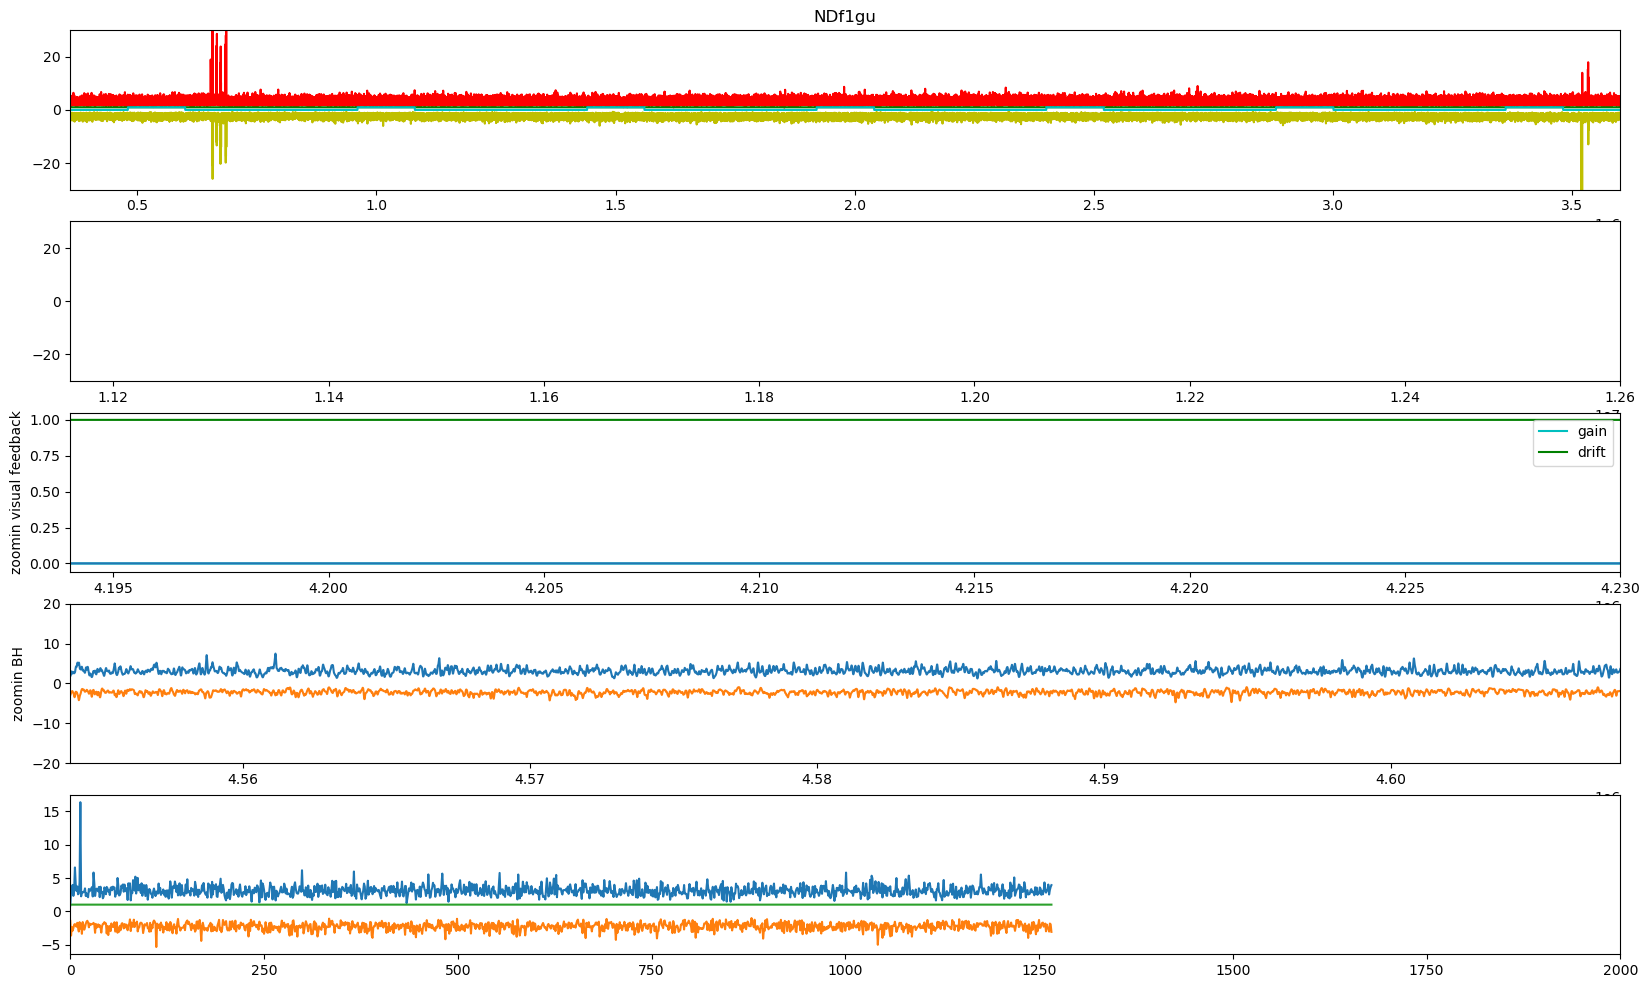

are both channels usable? yes or no


 yes


Selecte your better channel: 0 or 1: top is 0, bottom is 1


 1


bh_ch1
choose scaling thr vale for channel 0


 2.0


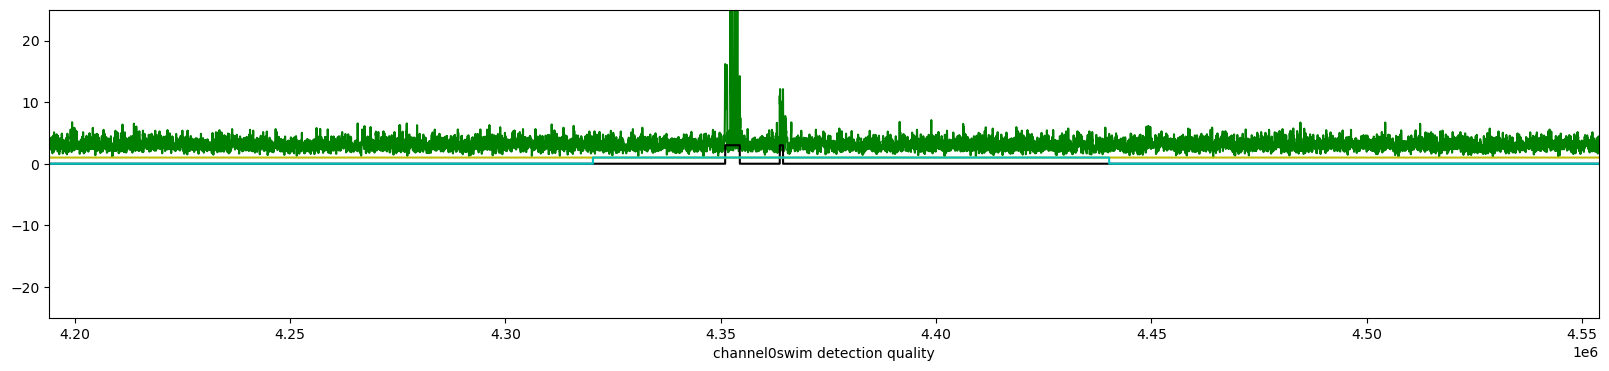

choose scaling thr vale for channel 1


 2.0


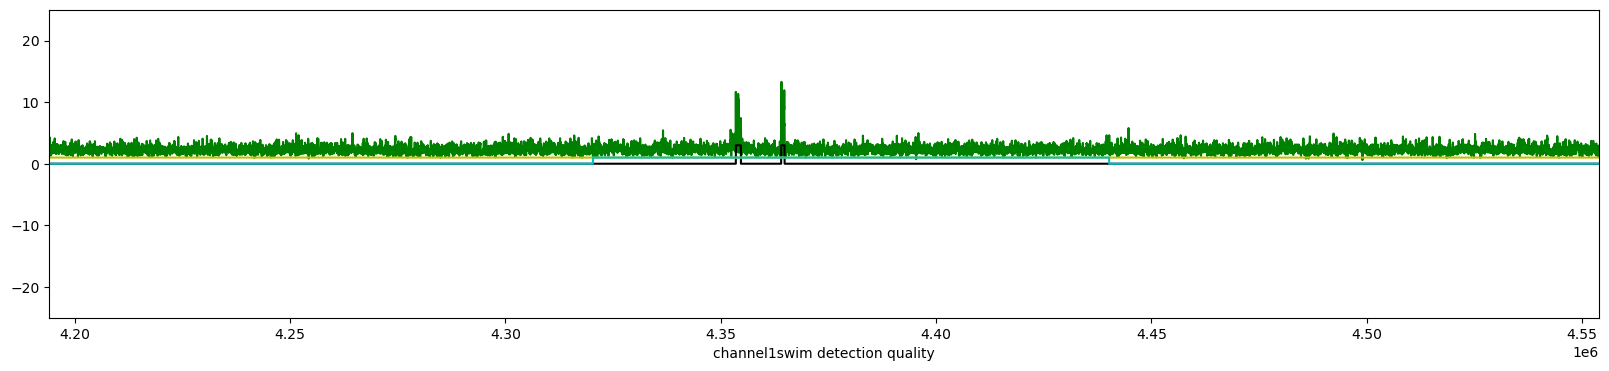

use both channel for Swim detection? yes or no


 yes


C:\Users\enyanglab\AppData\Local\Temp\ipykernel_23804\239986118.py:573: RuntimeWarning: invalid value encountered in scalar divide
  channelScaleFactor = pow1/pow0


done with both channels


In [62]:
# from astropy.convolution import convolve, Gaussian1DKernel, Box1DKernel
#gauss_kernel = Gaussian1DKernel(3.3)

for f in range(len(fnames)):
    eph = ime.import10ch(fnames[f])
    ephyst=ephys.load(fnames[f])
    base=os.path.basename(fnames[f])
    fname=os.path.splitext(base)[0]

    bh_ch0=eph['fltCh0']
    bh_ch1=eph['fltCh1']
    visual_input=eph['drift']
   
    fb=(-1)*ephyst[8] # the real velocity fish see, amplified
    
    tau1=300
    tau2=700
    turn_ker = np.concatenate((np.ones(tau1),1-np.arange(1,tau2,1)/tau2))
    
   # sd=ephyst[8]-ephyst[8].min() # the gain*power part
    
    gain=eph['gain']
    drift=eph['drift']
    #fb=ephyst[8]*(-1)

    
    fig,axes = plt.subplots(nrows=5, ncols=1,figsize=(20,12))
    axes[0].plot(bh_ch0/bh_ch0.std(),'r')
    axes[0].plot((-1)*bh_ch1/bh_ch1.std(),'y')
    axes[0].plot(drift,'g')
    axes[0].plot(gain*50,'c')
    axes[0].set_xlim(1*60*6000,10*60*6000)
    axes[0].set_ylim(-30,30)
    axes[0].set_title(fname)
    
    axes[1].plot(bh_ch0/bh_ch0.std())
    axes[1].plot((-1)*bh_ch1/bh_ch1.std())
    axes[1].plot(drift)
    #axes[1].set_xlim(15*60*6000,25*60*6000)
    axes[1].set_xlim(31*60*6000,35*60*6000)
    axes[1].set_ylim(-30,30)

    axes[2].plot(gain*50,'c',label='gain')
    axes[2].plot(drift,'g',label='drift')
    axes[2].plot(fb)
    axes[2].set_ylabel('zoomin visual feedback')
    axes[2].set_xlim(11.65*60*6000,11.75*60*6000)
    axes[2].legend(loc=1)
    
    axes[3].plot(bh_ch0/bh_ch0.std())
    axes[3].plot((-1)*bh_ch1/bh_ch1.std())
    axes[3].set_ylabel('zoomin BH')
    axes[3].set_xlim(12.65*60*6000,12.80*60*6000)
    axes[3].set_ylim(-20,20)

        
    axes[4].plot(bh_ch0[::6000]/bh_ch0.std())
    axes[4].plot((-1)*bh_ch1[::6000]/bh_ch1.std())
    axes[4].plot(drift[::6000])
    axes[4].set_xlim(0,2000)
    #axes[4].set_ylim(-30,30)
     


    plt.savefig(behDir+fname+'_example.pdf')
    plt.show()
    
    channels=[bh_ch0,bh_ch1]
    
    sides=['left','right']
    dfs_10=[]
    # ask user to select a channel
    print("are both channels usable? yes or no")
    name1 = input()
    
    if name1=='yes':
        l=(0,1)
        print("Selecte your better channel: 0 or 1: top is 0, bottom is 1")
        name3 = input()
        if name3== '0':
            d=0
            print("bh_ch0")
        if name3=='1':
            d=1
            print("bh_ch1")    

    if name1=='no':
# ask user to select a channel
        print("Selecte your channel: 0 or 1: top is 0, bottom is 1")

    # take user input
        name = input()
        if name== '0':
            l=(0,)
            print("selected_ch = bh_ch0")
        if name=='1':
            l=(1,)
            print("selected_ch = bh_ch1")    

    for c in l:
        print("choose scaling thr vale for channel "+str(c))
        name_th=input()
        
        selected_ch=channels[c]
        cha=sides[c]
        



        starts,ends,thr,bursts=ime.getSwims(selected_ch,th=float(name_th))  # scaling factor th often needs to be changed if signal is smallboth

        selected_swim_temp=np.zeros(len(starts))
        swim_off_all=np.where(ends==1)[0]
        swim_on_all=np.where(starts==1)[0] 

        for j in range(len(swim_on_all)):
            selected_swim_temp[swim_on_all[j]:swim_off_all[j]+1]=1


        plt.figure(figsize=(20,4))
        plt.plot(selected_ch/selected_ch.std(),'g')
        plt.plot(selected_swim_temp*3,'k')
        plt.plot(drift,'y')
        plt.plot(gain*50,'c')
        plt.xlim(11.65*60*6000,12.65*60*6000)
        plt.ylim(-25,25)
        plt.xlabel('channel'+str(c)+'swim detection quality')



        plt.savefig(behDir+fname+str(c)+'_peak detection snipit.pdf')
        if name1=='no':
            np.save(behDir+fname+'swim_bout_detected.npy',selected_swim_temp)
        plt.show()
        #ch_sm0=ime.smoothPower(selected_ch, gauss_kernel)
        #con=np.convolve(selected_ch, gauss_kernel,'same')        
        ch_sm=selected_ch/selected_ch.std()

       
        
        
        base_velocity=(selected_swim_temp==0)*fb*(drift!=0)
        sd=fb-base_velocity
        
        """Always check this line for different paradigms"""
        """ These do not work for pulses. """
        #estart_inds=np.where((np.diff(drift)!=0)&(drift[:-1]==0))[0]
        #estop_inds=np.where((np.diff(drift)!=0)&(drift[1:]==0))[0]
        
        """these do not work for zero gains"""
        estart_inds=np.where((gain[:-1]==0)&(np.diff(gain)!=0))[0]
        estop_inds=np.where((gain[1:]==0)&(np.diff(gain)!=0))[0]
        
        if estart_inds[0]>=estop_inds[0]:
            estop_inds=estop_inds[1:]
        if estart_inds[0]>=estop_inds[0]:
            
            estop_inds=estop_inds[1:]    
        if estart_inds[0]>=estop_inds[0]:
            estop_inds=estop_inds[1:] 
        if estart_inds[-1]>=estop_inds[-1]:
            estart_inds=estart_inds[:-1] 

        estop_time=estart_inds[1:]-estop_inds[:-1]
        stop_time=np.round(estop_time/6000)
        ego_time=estop_inds-estart_inds
        go_time=np.round(ego_time/6000)[1:]
        #drift_now=np.zeros(estart_inds.shape)
        drift_now=drift[estart_inds+300][1:]
        drift_his=drift[estart_inds+300][:-1]
        
       

        """
        very likely need to be changed
        """
       # estop_time= estop_time[:-1]# special case here!!!!!!!


        #ego_time= ego_time[:-1]# special case here!!!!!!!
       # go_time=go_time[:-1]# special case here!!!!!!!
       # stop_time=stop_time[:-1]# special case here!!!!!!!
        
        

        firstbout_power=np.zeros(len(estop_time))
        eresp_time=np.zeros(len(estop_time))
        last_bout_time=np.zeros(len(estop_time))
        mask=np.zeros(len(estop_time))
        mask2=np.zeros(len(estop_time))
        mask3=np.zeros(len(estop_time))
        behavior_hist=np.zeros(len(estop_time))
        behavior_now=np.zeros(len(estop_time))
        swim_dist=np.zeros(len(estop_time))
        visual_feedback=np.zeros(len(estop_time))
        swim_result=np.zeros(len(estop_time))
        swim_result_now=np.zeros(len(estop_time))
        
        
        swim_time=np.zeros(len(estop_time))
        bout_duration_ave=np.zeros(len(estop_time))
        bout_interval=np.zeros(len(estop_time))
        bout_number=np.zeros(len(estop_time))
        first_bstart_ind=np.zeros(len(estop_time))
        first_bend_ind=np.zeros(len(estop_time))
        gain_his=np.zeros(len(estop_time))
        gain_pre=np.zeros(len(estop_time))
        visual_input_hist=np.zeros(len(estop_time))
        vh_type=np.zeros(len(estop_time))
        visual_hist_long=np.zeros(len(estop_time))


        first_bout_duration=np.zeros(len(estop_time))
        pulse_time=np.zeros(len(estop_time))
        mem_time=np.zeros(len(estop_time))

        pulse_dir=np.zeros(len(estop_time))
        mem_dir=np.zeros(len(estop_time))

        mem_len=np.zeros(len(estop_time))
        delay_len=np.zeros(len(estop_time))
        vh_len=np.zeros(len(estop_time))
        pulse_len=np.zeros(len(estop_time))
        RT_ds=np.zeros(len(estop_time))
        RT_ds_thr=np.zeros(len(estop_time))
        last_bout_ds=np.zeros(len(estop_time))
        
        """
        determine turn from singel channel
        """
        first_turn_angle0=np.zeros(len(estop_time))
        first_half_burst_power=np.zeros(len(estop_time))
        initial_swim_response=np.zeros(estop_time.shape)
       # for i in range(len(estop_time)):


        


        for i in range(len(estop_time)):
            period=estart_inds[i+1]+np.arange(ego_time[i+1])# time period to analyze current (future)swim
            swim_on=starts[period]
            swim_off=ends[period]
            behavior_now[i]=np.trapz(ch_sm[period]*selected_swim_temp[period],dx=1)
            swim_result_now[i]=np.trapz(fb[period],dx=1)
            
            
            if selected_swim_temp[period].any():
                first_peak_ind=(np.where(selected_swim_temp[period]!=0)[0]).min()+estart_inds[i+1]
                first_half_burst_power[i]=selected_ch[first_peak_ind-300+np.arange(500)].sum()

            period13=estart_inds[i+1]-1-np.arange(estop_time[i]-1) 
            period_long=estart_inds[i+1]-1-np.arange(estop_time[i]+ego_time[i]-1) 
            period_s=estart_inds[i+1]-estop_time[i]+np.arange(6*6000) 
            visual_input_hist[i]=np.trapz(fb[period13],dx=1)
            vh_type[i]=np.trapz(fb[period_s],dx=1) # this is to differentiate same total distance but different randomness
                    
            visual_hist_long[i]=np.trapz(fb[period_long],dx=1) #np.trapz(fb[period]*100,dx=1)
            period2=estart_inds[i+1]-np.arange(estop_time[i]-1*6000) # time period swim is not allowed
            period2_bc=estart_inds[i+1]+2-np.arange(estop_time[i]-1*6000) # time period swim is not allowed
            period2_1=estart_inds[i+1]-np.arange(int(3.5*6000) )# time period swim is not allowed 
            period2_2=estart_inds[i+1]-np.arange(int(6*6000) )# time period swim is not allowed  
            
         
            'for ablation 115 experiments only'
            pulse_tag=drift[period2_bc] 
            #pulse_tag=drift[period2_bc]

            swim_unwanted=starts[period2_1]
            swim_unwanted2=starts[period2_2]
            swim_unwanted3=starts[period2]
            period4=estop_inds[i]+1*6000-np.arange(ego_time[i]+1*6000)#  time period to analyze past swim history
            #swim_his_event=starts[period4]
            swim_result[i]=np.trapz(fb[period4],dx=1)
            gain_his[i]=gain[estart_inds[i]+1]
            gain_pre[i]=gain[estart_inds[i+1]+1]
            swim_on_his=starts[period4]
            swim_off_his=ends[period4]
            


           # if (pulse_tag!=0).any():# here if the drift was not to zero, anything would work as long as it increase forvisual
            #pulse_time[i]=np.round((np.where(pulse_tag!=0)[0]).min()/6) 
            #pulse_dir[i]=pulse_tag[(np.where(pulse_tag!=0)[0]).min()]
            pulse_ind=np.where(np.diff(pulse_tag)!=0)[0] # changes, at least one
            pulse_loc=np.where(pulse_tag!=0)[0] 
            if len(pulse_ind)>1:
                if len(pulse_ind)==2:
                    pulse_time[i]=np.round((pulse_loc[5])/6)
                    pulse_dir[i]=pulse_tag[pulse_loc[5]]
                    pulse_len[i]=np.diff(pulse_ind)[-1]/6
               
                if len(pulse_ind)>2:
                    pulse_time[i]=np.round((pulse_loc[5])/6) # remember with bc there is no diff 1
                    pulse_dir[i]=pulse_tag[pulse_loc[5]]
                    pulse_len[i]=np.diff(pulse_ind)[1]/6
                    
                    if (pulse_loc[-1]/6)>4500:
          
                        delay_len[i]=(pulse_ind[-2])/6
                        mem_len[i]=np.diff(pulse_ind)[-1]/6
                        mem_time[i]=np.round((pulse_ind[-1]/6))
                        mem_dir[i]=pulse_tag[pulse_loc[-5]]

                vh_len[i]=np.round(((np.where(pulse_tag!=0)[0]).max()-(np.where(pulse_tag!=0)[-1]).min())/6)

            else:
                vh_len[i]=0
                mem_len[i]=0
                pulse_len[i]=0
                delay_len[i]=0
                mem_time[i]=estop_time[i]/6
                pulse_time[i]=estop_time[i]/6
                mem_dir[i]=0
                pulse_dir[i]=0



            if (swim_on.any())&(swim_off.any()):

                swim_on_ind=np.where( swim_on==1)[0]
                swim_off_ind=np.where( swim_off==1)[0]

                if swim_on_ind[0]>swim_off_ind[0]:
                    swim_off_ind=swim_off_ind[1:]

                if swim_off_ind.any():
                    if swim_on_ind[-1]>swim_off_ind[-1]:
                        swim_on_ind=swim_on_ind[:-1] 


                    eresp_time[i]=swim_on_ind.min()/6
                    last_bout_time[i]=swim_off_ind.max()/6




                    #this=np.where(swim_event==1)[0].min()
                    firstbout_power[i]=np.trapz(ch_sm[period][ swim_on_ind[0]:swim_off_ind[0]],dx=1)
                    first_bout_duration[i]=swim_off_ind[0]-swim_on_ind[0]
                    first_bstart_ind[i]=swim_on_ind[0]
                    first_bend_ind[i]=swim_off_ind[0]



                    bout_duration_ave[i]=(swim_off_ind-swim_on_ind).mean()
                    bout_interval[i]=(swim_on_ind[1:]-swim_off_ind[:-1]).mean()
                    bout_number[i]=swim_on_ind.shape[0]
                else:
                    eresp_time[i]=swim_on_ind.min()/6
                    last_bout_time[i]=go_time[i]

                    firstbout_power[i]=np.trapz(ch_sm[period][ swim_on_ind[0]:-1],dx=1)
                    first_bout_duration[i]=period[-1]-swim_on_ind[0]
                    first_bstart_ind[i]=swim_on_ind[0]
                    first_bend_ind[i]=period[-1]



                    bout_duration_ave[i]=first_bout_duration[i]
                    bout_interval[i]=0
                    bout_number[i]=swim_on_ind.shape[0]



            else:
                eresp_time[i]= ego_time[i+1]/6
            periodSS=estart_inds[i]+eresp_time[i]+np.arange(6*200)#  first 200 ms of swimming
            initial_swim_response[i]=(np.trapz(ch_sm[periodSS.astype(int)])) #/df['RT'].iloc[i] 


            if swim_unwanted.any():
                mask[i]=0
            else:
                mask[i]=1

            if swim_unwanted2.any():
                mask2[i]=0
            else:
                mask2[i]=1   

            if swim_unwanted3.any():
                mask3[i]=0
            else:
                mask3[i]=1  

            if (swim_off_his.any())&(swim_on_his.any()):

                swim_on_ind_his=np.where( swim_on_his==1)[0]
                swim_off_ind_his=np.where( swim_off_his==1)[0]
                if swim_on_ind_his[0]>swim_off_ind_his[0]:
                    swim_off_ind_his=swim_off_ind_his[1:]

                if  swim_off_ind_his.any():

                    if swim_on_ind_his[-1]>swim_off_ind_his[-1]:
                        swim_on_ind_his=swim_on_ind_his[:-1]

                behavior_hist[i]=np.trapz(ch_sm[period4]*selected_swim_temp[period4],dx=1)
                visual_feedback[i]=np.trapz(fb[period4]*selected_swim_temp[period4],dx=1)
                swim_dist[i]=np.trapz(sd[period4]*selected_swim_temp[period4],dx=1)
                
                swim_time[i]=(swim_off_ind_his-swim_on_ind_his).sum()/6

            else:
                behavior_hist[i]=0
                swim_dist[i]=0
                swim_time[i]=0
        
        base=first_half_burst_power[np.where(drift_now==1)].mean() # depends on the setting
        #base=90  # for backward only
        max_pow=first_half_burst_power.max()
        for i in range(len(estop_time)): 
             if first_half_burst_power[i]>base:
                    first_turn_angle0[i]=(first_half_burst_power[i]-base)/(max_pow-base)*(180)
                    if first_turn_angle0[i]>180:
                        first_turn_angle0[i]=180
        
        
        RT=eresp_time# reaction time
        BH=behavior_hist # swim power and time
        ST=swim_time# swim time
        SD=swim_dist # swim distance
        VH=visual_input_hist
        FP=firstbout_power
        if c==0:
            selected_swim0=selected_swim_temp
        if c==1:
            
            selected_swim1=selected_swim_temp



        df = pd.DataFrame({'VH': visual_input_hist,
                           'VH_long':visual_hist_long,
                           'rand_type':vh_type,
                           'BH': behavior_hist,
                           'SD': swim_dist,
                           'VF':visual_feedback,
                           'swim_result':swim_result,
                           'SwimT': swim_time,
                           'mask_4s': mask,
                           'mask_6s': mask2,
                           'mask':mask3,
                           'RT':eresp_time, 
                           'swim_result_post':swim_result_now,
                           'BH_post': behavior_now,
                           'estart_inds':estart_inds[1:],
                           'estop_inds':estop_inds[1:],


                           'FP': firstbout_power,
                           'initial_motor_output':initial_swim_response,
                           'first_turn_angle':first_turn_angle0,
                           'STime':stop_time,
                           'goTime':go_time,
                           'gain_his':gain_his,
                           'gain_now':gain_pre,
                           'frist_bout_duration':first_bout_duration,
                           'bout_duration_ave':bout_duration_ave,
                           'bout_interval_ave':bout_interval,
                           'swim_end_time': last_bout_time,
                           'bout_number':bout_number,
                           'pulse_end_time':pulse_time,
                           'mem_start_time':mem_time,
                           
                           'drift_now':drift_now,
                           'drift_his':drift_his,

                           'pulse_dir':pulse_dir,
                           'mem_dir':mem_dir,
                           'pulse_len':pulse_len,#last pulse length
                           'mem_len':mem_len, # first pulse length
                           'vh_len':vh_len,
                           'delay_len':delay_len, #largest gap between of pulse diff


                          })

        df.to_csv(behDir+fname+cha+'.xls')
        dfs_10.append((df))
    
    if name1=='no': 
        selected_swim_t=selected_swim_temp
        swim_starts=np.where(np.diff(selected_swim_t)>0)[0]
        swim_ends=np.where(np.diff(selected_swim_t)<0)[0]
        every_bout_power=np.zeros(len(swim_starts))
        
        every_bout_duration=np.zeros(len(swim_starts))
        every_bout_interval=np.zeros(len(swim_starts))
        last_bout_power=np.zeros(len(swim_starts))
        #drift_cur=np.zeros(swim_starts.shape)
        drift_cur=drift[swim_starts]
        gain_cur=gain[swim_starts]
        





        for i in range(len(swim_starts)-1):
 
            LRW=selected_ch[swim_starts[i]-80:swim_ends[i]].sum()
             
            every_bout_power[i]=LRW
            every_bout_duration[i]=swim_ends[i]-swim_starts[i]
            if gain_cur[i]!=gain_cur[i+1]:
                last_bout_power[i]=every_bout_power[i]
                every_bout_interval[i]=0
            else:
                if swim_starts[i+1]-swim_ends[i]>estop_time[1]:
                    every_bout_interval[i]=0
                else:
                    every_bout_interval[i]=swim_starts[i+1]-swim_ends[i]
            

        df2 = pd.DataFrame({'drift_cur': drift_cur,
                           
                            'gain_cur':gain_cur,
                            
                            'bout_power':every_bout_power,
                            'every_bout_duration':every_bout_duration,
                            'every_bout_interview':every_bout_interval,
                            'last_bout_power':last_bout_power,

                           })
        np.save(behDir+fname+'swim_bout_detected_single_ch.npy',selected_swim_t)
        df2.to_csv(behDir+fname+'_all_swims_single_channle_forward_swims.xls')

    if name1=='yes': 
        print("use both channel for Swim detection? yes or no")
        name_add = input()
    
        if name_add=='yes':
            
            selected_swim_t=np.maximum(selected_swim1,selected_swim0) # both signal has to be super good. false positive will change results
        if name_add=='no':
            print('which channel for swim detection? 0 (top) or 1 (bottom)')
            name_add2=input()
            if name_add2=='0':
                print("bh_ch0")
                selected_swim_t=selected_swim0
            if name_add2=='1':
                selected_swim_t=selected_swim1
                print("bh_ch1")
                
                
        swim_starts=np.where(np.diff(selected_swim_t)>0)[0]
        swim_ends=np.where(np.diff(selected_swim_t)<0)[0]
        every_bout_power=np.zeros(len(swim_starts))
        TT=np.zeros(len(swim_starts))
        every_bout_duration=np.zeros(len(swim_starts))
        every_bout_interval=np.zeros(len(swim_starts))
        last_bout_power=np.zeros(len(swim_starts))
        #drift_cur=np.zeros(swim_starts.shape)
        drift_cur=drift[swim_starts]
        gain_cur=gain[swim_starts]
        





        for i in range(len(swim_starts)-1):

            if swim_ends[i]- swim_starts[i] < len(turn_ker):
                multip = len(turn_ker) / (200 + swim_ends[i]- swim_starts[i] )
            else:
                multip = 1
            #period=swim_starts[i]-80+np.arange(len(turn_ker))
            pow1=bh_ch1[swim_starts[i]-50000:swim_ends[i]+50000].sum()
            pow0=bh_ch0[swim_starts[i]-50000:swim_ends[i]+50000].sum()
            channelScaleFactor = pow1/pow0
            LL_raw=bh_ch0[swim_starts[i]-80:swim_starts[i]-80+len(turn_ker)]
            RR_raw=bh_ch1[swim_starts[i]-80:swim_starts[i]-80+len(turn_ker)]
            LL = (bh_ch0[swim_starts[i]-80:swim_starts[i]-80+len(turn_ker)]*turn_ker[:len(LL_raw)]).sum()
            RR = (bh_ch1[swim_starts[i]-80:swim_starts[i]-80+len(turn_ker)]*turn_ker[:len(RR_raw)]).sum()
            TT[i] = (channelScaleFactor*LL - RR) * multip 
            LLw=bh_ch0[swim_starts[i]-80:swim_ends[i]].sum()
            RRw=bh_ch1[swim_starts[i]-80:swim_ends[i]].sum()
            every_bout_power[i]=(channelScaleFactor*LLw + RRw)
            every_bout_duration[i]=swim_ends[i]-swim_starts[i]
            if gain_cur[i]!=gain_cur[i+1]:
                last_bout_power[i]=every_bout_power[i]
                every_bout_interval[i]=0
            else:
                if swim_starts[i+1]-swim_ends[i]>estop_time[1]:
                    every_bout_interval[i]=0
                else:
                    every_bout_interval[i]=swim_starts[i+1]-swim_ends[i]
            

        df2 = pd.DataFrame({'drift_cur': drift_cur,
                            'turn_index':TT,
                            'gain_cur':gain_cur,
                            'turn_index_amp':abs(TT),
                            'bout_power':every_bout_power,
                            'every_bout_duration':every_bout_duration,
                            'every_bout_interview':every_bout_interval,
                            'last_bout_power':last_bout_power,

                           })
        np.save(behDir+fname+'swim_bout_detected.npy',selected_swim_t)
        df2.to_csv(behDir+fname+'_all_swims_doule_channle_turn_index.xls')
        
    
    
   
        a=0
        b=1

        trial_num=len(dfs_10[a])
        first_power=np.zeros(trial_num)
        turn_deg=np.zeros(trial_num)
        reaction_time=np.zeros(trial_num)
        first_bout_duration=np.zeros(trial_num)
        TT_first=np.zeros(trial_num)
        initial_motor=np.zeros(trial_num)


        fdl=dfs_10[a]['frist_bout_duration'].mean()
        fdr=dfs_10[b]['frist_bout_duration'].mean()
        #fpl=dfs_10[a][(dfs_10[a]['pulse_dir']==0)]['FP'].mean() # can change depends on the paradigm, could be mean of no pulse
        fpl=dfs_10[a]['FP'].mean()
        fpr=dfs_10[b]['FP'].mean()
        fpd=dfs_10[d]['FP'].mean()
        q=pd.concat([dfs_10[a]['swim_end_time'],dfs_10[b]['swim_end_time']],axis=1)
        last_swim_time=q.max(axis=1)

        
        for num in range(trial_num):
            period21=estart_inds[num+1]+np.arange(ego_time[num+1])
            #period22=estart_inds[num+1]+np.arange(ego_time[num+1]+60000) # sometimes first swim ends after the go cue, some times overflow
            if  selected_swim_t[period21].any():
                first_start_ind=(np.where(selected_swim_t[period21]!=0)[0]).min()+estart_inds[num+1]
                if (np.diff(selected_swim_t[period21])<0).any():
                    first_end_ind=(np.where(np.diff(selected_swim_t[period21])<0)[0]).min()+estart_inds[num+1]
                else:
                    first_end_ind=estop_inds[num+1]

                if first_end_ind - first_start_ind < len(turn_ker):
                    multip = len(turn_ker) / (200 + first_end_ind- first_start_ind )
                else:
                    multip = 1


               # period3=[]

                pow1=bh_ch1[first_start_ind-50000:first_end_ind+50000].sum()
                pow0=bh_ch0[first_start_ind-50000:first_end_ind+50000].sum()
                channelScaleFactor = pow1/pow0


                LL_raw=bh_ch0[first_start_ind-80:first_start_ind-80+len(turn_ker)]
                LL_raw1=bh_ch0[first_start_ind:first_start_ind+6*200]
                
                RR_raw=bh_ch1[first_start_ind-80:first_start_ind-80+len(turn_ker)]
                RR_raw1=bh_ch0[first_start_ind:first_start_ind+6*200]
                
                LL = (bh_ch0[first_start_ind-80:first_start_ind-80+len(turn_ker)]*turn_ker[:len(LL_raw)]).sum() # try avoid arange for overflow
                RR = (bh_ch1[first_start_ind-80:first_start_ind-80+len(turn_ker)]*turn_ker[:len(RR_raw)]).sum()
                TT_first[num] = (channelScaleFactor*LL - RR) * multip
                
                initial_motor[num]=(channelScaleFactor*LL_raw1.sum() + RR_raw1.sum())
                
            else:
                TT_first[num] = 0


            direction=dfs_10[a]['RT'][num]-dfs_10[b]['RT'][num]
            if direction==0:
                turn_deg[num]=0

                first_power[num]=dfs_10[d]['FP'][num]/fpd
                reaction_time[num]=dfs_10[d]['RT'][num]
                first_bout_duration[num]=dfs_10[d]['frist_bout_duration'][num] 
            if direction<0:
                turn_deg[num]=np.min([(-1)*direction*360/fdl,360]) # make it positive value to be consistent with turn inde power method

                first_power[num]=dfs_10[a]['FP'][num]/fpl
                reaction_time[num]=dfs_10[a]['RT'][num]
                first_bout_duration[num]=dfs_10[a]['frist_bout_duration'][num]
            if direction>0:
                turn_deg[num]=np.max([(-1)*direction*360/fdr,-360])# make it negtive direction to be consistent with turn index method

                first_power[num]=dfs_10[b]['FP'][num]/fpr
                reaction_time[num]=dfs_10[b]['RT'][num]
                first_bout_duration[num]=dfs_10[b]['frist_bout_duration'][num]


            df3 = pd.DataFrame({
                       'turn_dir': turn_deg, 
                       'turn_amp': abs(turn_deg),
                       'first_turn_index':TT_first,
                
                
                       'first_turn_index_amp':abs(TT_first),
                       'initial_motor_output':initial_motor,


                       'BH': dfs_10[a]['BH']+dfs_10[b]['BH'],
                       'BH_post': dfs_10[a]['BH_post']+dfs_10[b]['BH_post'],

                       'SwimT_ave': (dfs_10[a]['SwimT']+dfs_10[b]['SwimT'])/2,


                       'RT':reaction_time, 
                       'VH_long':dfs_10[d]['VH_long'],



                       'FP': first_power,
                       'frist_bout_duration':first_bout_duration,
                       'swim_end_time': last_swim_time,
                       'bout_duration_ave_ave':(dfs_10[a]['bout_duration_ave']+dfs_10[b]['bout_duration_ave'])/2,
                       'bout_interval_ave_ave':(dfs_10[a]['bout_interval_ave']+dfs_10[b]['bout_interval_ave'])/2,

                       'bout_number_ave':(dfs_10[a]['bout_number']+dfs_10[b]['bout_number'])/2,

                       'SD': dfs_10[d]['SD'],
                       'VF':dfs_10[d]['VF'],
                       'VH':dfs_10[d]['VH'],
                       'swim_result':dfs_10[d]['swim_result'],
                       'swim_result_post':dfs_10[d]['swim_result_post'],

                       'pulse_end_time':dfs_10[d]['pulse_end_time'],
                       'mem_start_time':dfs_10[d]['mem_start_time'],
                       'STime':dfs_10[d]['STime'],
                       'goTime':dfs_10[d]['goTime'],
                       'drift_now':drift_now,
                       'drift_his':drift_his,


                       'gain_his':dfs_10[d]['gain_his'],
                       'gain_now':dfs_10[d]['gain_now'],

                       'pulse_dir':dfs_10[d]['pulse_dir'],
                       'mem_dir':dfs_10[d]['mem_dir'],
                       'pulse_len':dfs_10[d]['pulse_len'],#last pulse length
                       'mem_len':dfs_10[d]['mem_len'], # first pulse length
                       'vh_len':dfs_10[d]['vh_len'],#largest gap between of pulse diff
                       'delay_len':dfs_10[d]['delay_len'],
                       'mask_4s': dfs_10[d]['mask_4s'],
                       'mask_6s':dfs_10[d]['mask_6s'] ,
                       'mask':dfs_10[d]['mask'],


                      })

        df3.to_csv(behDir+fname+'_both.xls')
        print('done with both channels')
    else:
        print("done with selected channel")






# quick check

In [79]:
behDir

'D:/Millen/20241020/'

In [89]:
#fnames3=glob.glob(behDir+'both channel_swim_detect/*turn*.xls')
fnames3=glob.glob(behDir+'*NDf1_both*.xls')
fnames3.sort()
fnames3

['D:/Millen/20241020\\NDf1_both.xls']

In [91]:
fnames3

['D:/Millen/20241020\\NDf1_both.xls']

In [93]:

i=0

df2=pd.read_csv(fnames3[i])
fish_name=os.path.basename(fnames3[i])
print(fish_name)


NDf1_both.xls


In [95]:
df2.columns

Index(['Unnamed: 0', 'turn_dir', 'turn_amp', 'first_turn_index',
       'first_turn_index_amp', 'initial_motor_output', 'BH', 'BH_post',
       'SwimT_ave', 'RT', 'VH_long', 'FP', 'frist_bout_duration',
       'swim_end_time', 'bout_duration_ave_ave', 'bout_interval_ave_ave',
       'bout_number_ave', 'SD', 'VF', 'VH', 'swim_result', 'swim_result_post',
       'pulse_end_time', 'mem_start_time', 'STime', 'goTime', 'drift_now',
       'drift_his', 'gain_his', 'gain_now', 'pulse_dir', 'mem_dir',
       'pulse_len', 'mem_len', 'vh_len', 'delay_len', 'mask_4s', 'mask_6s',
       'mask'],
      dtype='object')

In [97]:
df2.shape

(88, 39)

Text(0, 0.5, 'Reaction time')

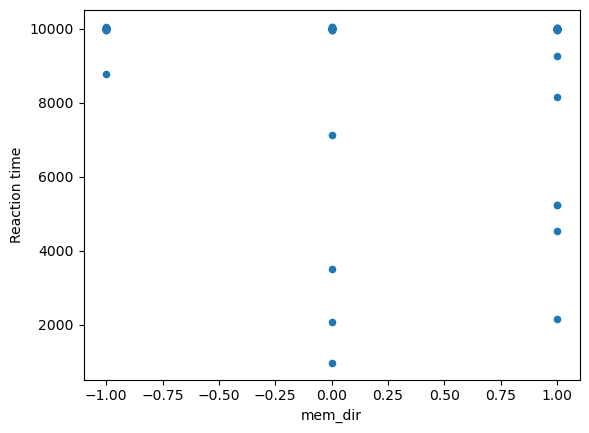

In [99]:
df2[15:].plot.scatter("mem_dir","RT") # exclude first 5 minutes
plt.ylabel("Reaction time")

df2.boxplot('BH_post',"mem_dir")

IndexError: single positional indexer is out-of-bounds

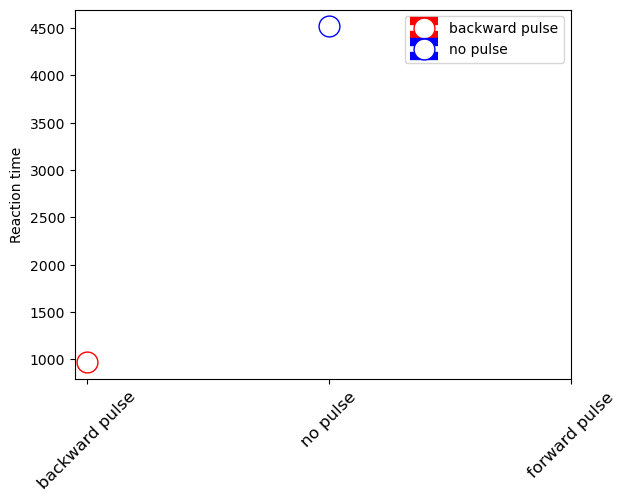

In [105]:

fmts=['ro','bo','go','mo','co','yo']
colors=['r','b','g','m','c','y']
labels=['backward pulse','no pulse','forward pulse','20','25','30']
new_df1=df2[(df2['RT']<9000)&(df2['mask']==0)]
#new_df1=dfs_20[a]
input_control='mem_dir'
#input_control=rs5
output_behavior='RT'
#output_behavior='turn_amp'
for i in range(0,3,1):
    #plt.scatter((i+1)*5,new_df.groupby(input_control)[output_behavior].mean().iloc[i],color=colors[i])
    plt.errorbar(i-1,new_df1.groupby(input_control)[output_behavior].mean().iloc[i],new_df1.groupby(input_control)[output_behavior].sem().iloc[i],fmt=fmts[i],markersize=15,capsize=10,capthick=6,
                 ecolor=colors[i],mfc='white',zorder=1,label=labels[i])
   # plt.title(name[a])
    plt.ylabel('Reaction time')
   # plt.xtitle('pulse direction')
    plt.xticks([-1,0,1], ['backward pulse','no pulse','forward pulse',],fontsize=(12),rotation=45) 
  
    
    plt.legend()

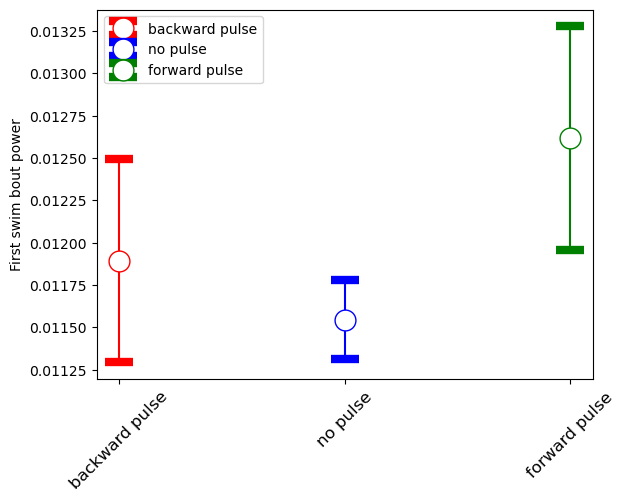

In [349]:

fmts=['ro','bo','go','mo','co','yo']
colors=['r','b','g','m','c','y']
labels=['backward pulse','no pulse','forward pulse','20','25','30']
new_df1=df2[(df2['RT']<9000)&(df2['mask_4s']==1)]
#new_df1=dfs_20[a]
input_control='mem_dir'
#input_control=rs5
#output_behavior='FP'
output_behavior='initial_motor_output'
for i in range(0,3,1):
    #plt.scatter((i+1)*5,new_df.groupby(input_control)[output_behavior].mean().iloc[i],color=colors[i])
    plt.errorbar(i-1,new_df1.groupby(input_control)[output_behavior].mean().iloc[i],new_df1.groupby(input_control)[output_behavior].sem().iloc[i],fmt=fmts[i],markersize=15,capsize=10,capthick=6,
                 ecolor=colors[i],mfc='white',zorder=1,label=labels[i])
   # plt.title(name[a])
    plt.ylabel('First swim bout power')
    plt.xticks([-1,0,1], ['backward pulse','no pulse','forward pulse',],fontsize=(12),rotation=45) 
  
    
    plt.legend()

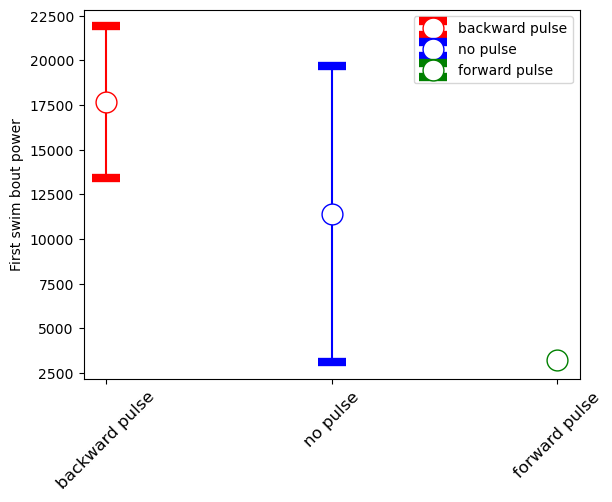

In [351]:

fmts=['ro','bo','go','mo','co','yo']
colors=['r','b','g','m','c','y']
labels=['backward pulse','no pulse','forward pulse','20','25','30']
new_df1=df2[(df2['RT']<9000)&(df2['mask']==0)]
#new_df1=dfs_20[a]
input_control='mem_dir'
#input_control=rs5
output_behavior='BH_post'
#output_behavior='turn_amp'
for i in range(0,3,1):
    #plt.scatter((i+1)*5,new_df.groupby(input_control)[output_behavior].mean().iloc[i],color=colors[i])
    plt.errorbar(i-1,new_df1.groupby(input_control)[output_behavior].mean().iloc[i],new_df1.groupby(input_control)[output_behavior].sem().iloc[i],fmt=fmts[i],markersize=15,capsize=10,capthick=6,
                 ecolor=colors[i],mfc='white',zorder=1,label=labels[i])
   # plt.title(name[a])
    plt.ylabel('First swim bout power')
    plt.xticks([-1,0,1], ['backward pulse','no pulse','forward pulse',],fontsize=(12),rotation=45) 
  
    
    plt.legend()

In [353]:
new_df1.shape

(17, 39)

# 